## Lab4 (test): RMSE-driven selection + polynomial/interactions

Цель: проверить, как меняется качество (главная метрика **RMSE** на контрольной выборке), если:

- расширить факторы линейно по параметрам: добавить квадраты и попарные взаимодействия
  \(\hat y = \beta_0 + \sum \beta_j x_j + \sum \beta_{jj}x_j^2 + \sum \beta_{jk}x_jx_k\);
- выбирать размерность \(p\) и набор факторов по **минимуму RMSE на контрольной** (Спирмен используется только как фильтр/ранжирование);
- оценивать устойчивость по серии случайных разбиений 50/50.

В этом ноутбуке **ничего не сохраняется в файлы** (только вывод/графики).


In [ ]:
import itertools
import math
from dataclasses import dataclass

import numpy as np
import pandas as pd

ALPHA = 0.05
Y_NAME = "Glucose"
DROP = {"Outcome", "Insulin"}

# 0 as missing: по смыслу (строго положительные измерения)
ZERO_AS_MISSING = {"BloodPressure", "SkinThickness", "BMI"}

_df = pd.read_csv("diabetes.csv")
X_NAMES = [c for c in _df.columns if c not in DROP and c != Y_NAME]

Y = _df[Y_NAME].astype(float).to_numpy()
X_df = _df[X_NAMES].astype(float)

print("Y =", Y_NAME)
print("X candidates =", X_NAMES)
print("n =", len(Y))
print("ZERO_AS_MISSING =", sorted(ZERO_AS_MISSING))


Y = Glucose
X candidates = ['Pregnancies', 'BloodPressure', 'SkinThickness', 'BMI', 'DiabetesPedigreeFunction', 'Age']
n = 768
ZERO_AS_MISSING = ['BMI', 'BloodPressure', 'SkinThickness']


In [ ]:
def split_idx(n: int, test_size: float, seed: int):
    rng = np.random.default_rng(seed)
    idx = np.arange(n)
    rng.shuffle(idx)
    m = int(round(n * test_size))
    te = np.sort(idx[:m])
    tr = np.sort(idx[m:])
    return tr, te


def apply_zero_as_missing(X: np.ndarray, names: list[str]):
    Xm = X.copy()
    for j, name in enumerate(names):
        if name in ZERO_AS_MISSING:
            Xm[Xm[:, j] == 0, j] = np.nan
    return Xm


def median_fit(X: np.ndarray):
    return np.nanmedian(X, axis=0)


def median_apply(X: np.ndarray, med: np.ndarray):
    X2 = X.copy()
    mask = ~np.isfinite(X2)
    if np.any(mask):
        X2[mask] = np.take(med, np.where(mask)[1])
    return X2


def robust_scale_fit(X: np.ndarray):
    # center=median, scale=IQR (Q3-Q1)
    center = np.median(X, axis=0)
    q1 = np.quantile(X, 0.25, axis=0)
    q3 = np.quantile(X, 0.75, axis=0)
    scale = q3 - q1
    scale = np.where(scale == 0, 1.0, scale)
    return center, scale


def robust_scale_apply(X: np.ndarray, center: np.ndarray, scale: np.ndarray):
    return (X - center) / scale


def rmse(y: np.ndarray, yhat: np.ndarray) -> float:
    y = np.asarray(y, float)
    yhat = np.asarray(yhat, float)
    return float(np.sqrt(np.mean((y - yhat) ** 2)))


def ols_beta(Z: np.ndarray, y: np.ndarray, ridge: float = 1e-10):
    A = Z.T @ Z + ridge * np.eye(Z.shape[1])
    b = Z.T @ y
    return np.linalg.solve(A, b)


def design_matrix(
    X_base_s: np.ndarray,
    base_names: list[str],
    add_squares: bool,
    add_interactions: bool,
):
    cols = [np.ones((X_base_s.shape[0], 1))]
    names = ["Intercept"]

    cols.append(X_base_s)
    names.extend([f"{n}*" for n in base_names])

    if add_squares:
        cols.append(X_base_s**2)
        names.extend([f"{n}*^2" for n in base_names])

    if add_interactions:
        inter_cols = []
        inter_names = []
        for i in range(len(base_names)):
            for j in range(i + 1, len(base_names)):
                inter_cols.append((X_base_s[:, i] * X_base_s[:, j])[:, None])
                inter_names.append(f"{base_names[i]}*·{base_names[j]}*")
        if inter_cols:
            cols.append(np.hstack(inter_cols))
            names.extend(inter_names)

    Z = np.hstack(cols)
    return Z, names


def spearman_rank_features(y: np.ndarray, Xdf: pd.DataFrame) -> list[str]:
    rho = Xdf.corrwith(pd.Series(y), method="spearman")
    return rho.abs().sort_values(ascending=False).index.tolist()


In [ ]:
@dataclass
class RunResult:
    seed: int
    p: int
    base_selected: list[str]
    rmse_control: float


def evaluate_one_split(
    seed: int,
    p_values: list[int],
    add_squares: bool,
    add_interactions: bool,
    spearman_top_m: int | None = None,
):
    n = len(Y)
    tr, te = split_idx(n, test_size=0.5, seed=seed)

    # Spearman ranking (на всей выборке можно было бы считать утечкой, поэтому считаем по рабочей)
    Xtr_df = X_df.iloc[tr]
    ytr = Y[tr]

    ordered = spearman_rank_features(ytr, Xtr_df)
    if spearman_top_m is not None:
        ordered = ordered[:spearman_top_m]

    results: list[RunResult] = []

    for p in p_values:
        base_sel = ordered[:p]

        # Base matrices
        Xm = X_df[base_sel].to_numpy(float)
        Xm = apply_zero_as_missing(Xm, base_sel)
        Xtr = Xm[tr]
        Xte = Xm[te]

        med = median_fit(Xtr)
        Xtr1 = median_apply(Xtr, med)
        Xte1 = median_apply(Xte, med)

        center, scale = robust_scale_fit(Xtr1)
        Xtr_s = robust_scale_apply(Xtr1, center, scale)
        Xte_s = robust_scale_apply(Xte1, center, scale)

        Ztr, _names = design_matrix(
            Xtr_s, base_sel, add_squares=add_squares, add_interactions=add_interactions
        )
        Zte, _ = design_matrix(
            Xte_s, base_sel, add_squares=add_squares, add_interactions=add_interactions
        )

        beta = ols_beta(Ztr, ytr)
        yhat_te = Zte @ beta
        r = RunResult(
            seed=seed,
            p=p,
            base_selected=base_sel,
            rmse_control=rmse(Y[te], yhat_te),
        )
        results.append(r)

    return results


def sweep_many_splits(
    seeds: list[int],
    p_values: list[int],
    add_squares: bool,
    add_interactions: bool,
    spearman_top_m: int | None = None,
):
    all_rows = []
    for s in seeds:
        res = evaluate_one_split(
            seed=s,
            p_values=p_values,
            add_squares=add_squares,
            add_interactions=add_interactions,
            spearman_top_m=spearman_top_m,
        )
        for r in res:
            all_rows.append(
                {
                    "seed": r.seed,
                    "p": r.p,
                    "rmse_control": r.rmse_control,
                    "selected": r.base_selected,
                }
            )

    df = pd.DataFrame(all_rows)
    summary = (
        df.groupby("p")["rmse_control"]
        .agg(["mean", "std", "min", "max"])
        .sort_values("mean")
        .reset_index()
    )
    best_p = int(summary.iloc[0]["p"]) if len(summary) else None
    return df, summary, best_p


In [ ]:
seeds = list(range(1, 21))  # 20 случайных разбиений 50/50
p_values = [2, 3, 4, 5, 6]

# Baseline: линейная модель по p базовым факторам (без квадратов/взаимодействий)
df_lin, sum_lin, best_p_lin = sweep_many_splits(
    seeds=seeds,
    p_values=p_values,
    add_squares=False,
    add_interactions=False,
    spearman_top_m=6,
)

# Expanded: квадраты + взаимодействия (линейно по параметрам)
df_poly, sum_poly, best_p_poly = sweep_many_splits(
    seeds=seeds,
    p_values=p_values,
    add_squares=True,
    add_interactions=True,
    spearman_top_m=6,
)

print("Baseline (linear only) RMSE on control: mean±std by p")
display(sum_lin)
print("best p (by mean RMSE):", best_p_lin)

print("\nExpanded (squares + interactions) RMSE on control: mean±std by p")
display(sum_poly)
print("best p (by mean RMSE):", best_p_poly)


Baseline (linear only) RMSE on control: mean±std by p


,p,mean,std,min,max
0,6,30.009797,1.243473,27.333221,31.928509
1,5,30.156756,1.196453,27.314479,31.901024
2,4,30.301624,1.149470,27.567308,31.912198
3,3,30.613301,1.207050,28.195078,33.120077
4,2,31.018490,1.229736,28.309431,32.634081


best p (by mean RMSE): 6

Expanded (squares + interactions) RMSE on control: mean±std by p


,p,mean,std,min,max
0,4,30.928282,1.107494,28.374702,32.800969
1,3,30.983652,1.157376,29.047227,33.404766
2,5,31.077999,1.179457,28.375607,33.124686
3,2,31.198027,1.148132,28.649952,32.900904
4,6,31.318660,1.270787,28.691122,33.821637


best p (by mean RMSE): 4


In [ ]:
def fit_and_show_one(seed: int, p: int, add_squares: bool, add_interactions: bool):
    n = len(Y)
    tr, te = split_idx(n, test_size=0.5, seed=seed)

    # Spearman ranking on working set
    ordered = spearman_rank_features(Y[tr], X_df.iloc[tr])
    base_sel = ordered[:p]

    Xm = X_df[base_sel].to_numpy(float)
    Xm = apply_zero_as_missing(Xm, base_sel)
    Xtr = Xm[tr]
    Xte = Xm[te]

    med = median_fit(Xtr)
    Xtr1 = median_apply(Xtr, med)
    Xte1 = median_apply(Xte, med)

    center, scale = robust_scale_fit(Xtr1)
    Xtr_s = robust_scale_apply(Xtr1, center, scale)
    Xte_s = robust_scale_apply(Xte1, center, scale)

    Ztr, names = design_matrix(
        Xtr_s, base_sel, add_squares=add_squares, add_interactions=add_interactions
    )
    Zte, _ = design_matrix(
        Xte_s, base_sel, add_squares=add_squares, add_interactions=add_interactions
    )

    beta = ols_beta(Ztr, Y[tr])
    yhat_tr = Ztr @ beta
    yhat_te = Zte @ beta

    print("seed=", seed, "p=", p)
    print("base selected (Spearman filter):", base_sel)
    print("RMSE working :", rmse(Y[tr], yhat_tr))
    print("RMSE control :", rmse(Y[te], yhat_te))

    # явная формула (в пространстве x* после робастной нормализации)
    # x* = (x - median_work)/IQR_work после медианной импутации пропусков
    parts = []
    for nm, b in zip(names, beta):
        if nm == "Intercept":
            continue
        parts.append(f"({b:+.5f})·{nm}")
    eq = f"yhat = ({beta[0]:.5f}) " + " ".join(parts)
    print("\nModel form (robust-scaled features):")
    print(eq)

    return te, yhat_te


# Для визуального сравнения берём один seed и лучший p по среднему RMSE
seed_show = 7

print("=== Baseline (linear only) ===")
te_lin, yhat_lin = fit_and_show_one(seed_show, best_p_lin, add_squares=False, add_interactions=False)

print("\n=== Expanded (squares + interactions) ===")
te_poly, yhat_poly = fit_and_show_one(seed_show, best_p_poly, add_squares=True, add_interactions=True)


=== Baseline (linear only) ===
seed= 7 p= 6
base selected (Spearman filter): ['SkinThickness', 'BMI', 'DiabetesPedigreeFunction', 'Pregnancies', 'BloodPressure', 'Age']
RMSE working : 30.493737701465566
RMSE control : 29.507811157130167

Model form (robust-scaled features):
yhat = (120.38016) (+1.96855)·SkinThickness* (+4.16626)·BMI* (+0.45493)·DiabetesPedigreeFunction* (-2.07576)·Pregnancies* (+5.01880)·BloodPressure* (+7.50615)·Age*

=== Expanded (squares + interactions) ===
seed= 7 p= 4
base selected (Spearman filter): ['SkinThickness', 'BMI', 'DiabetesPedigreeFunction', 'Pregnancies']
RMSE working : 30.644844997344478
RMSE control : 31.24299333819836

Model form (robust-scaled features):
yhat = (122.30412) (+1.98766)·SkinThickness* (+4.87241)·BMI* (-1.89449)·DiabetesPedigreeFunction* (+3.35801)·Pregnancies* (+1.75518)·SkinThickness*^2 (+1.15614)·BMI*^2 (+0.86308)·DiabetesPedigreeFunction*^2 (-1.26094)·Pregnancies*^2 (-6.99675)·SkinThickness*·BMI* (+0.32855)·SkinThickness*·DiabetesP

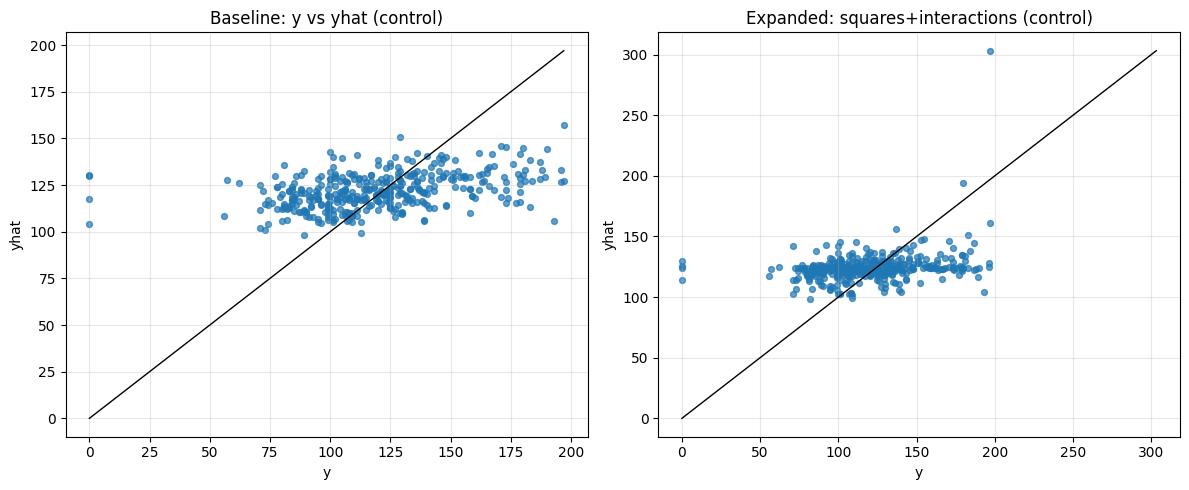

In [ ]:
import matplotlib.pyplot as plt

# Графики: y vs yhat на контрольной (baseline vs expanded)
# (идеал: точки вдоль линии y=yhat)

y_te_lin = Y[te_lin]
y_te_poly = Y[te_poly]

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# baseline
ax[0].scatter(y_te_lin, yhat_lin, s=18, alpha=0.7)
mn = float(min(y_te_lin.min(), yhat_lin.min()))
mx = float(max(y_te_lin.max(), yhat_lin.max()))
ax[0].plot([mn, mx], [mn, mx], color="black", linewidth=1)
ax[0].set_title("Baseline: y vs yhat (control)")
ax[0].set_xlabel("y")
ax[0].set_ylabel("yhat")
ax[0].grid(True, alpha=0.3)

# expanded
ax[1].scatter(y_te_poly, yhat_poly, s=18, alpha=0.7)
mn = float(min(y_te_poly.min(), yhat_poly.min()))
mx = float(max(y_te_poly.max(), yhat_poly.max()))
ax[1].plot([mn, mx], [mn, mx], color="black", linewidth=1)
ax[1].set_title("Expanded: squares+interactions (control)")
ax[1].set_xlabel("y")
ax[1].set_ylabel("yhat")
ax[1].grid(True, alpha=0.3)

fig.tight_layout()
plt.show()
